In [1]:
# Python imports
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
# JAX imports
from jax import config, jit, vmap
import jax.numpy as jnp
from jax.numpy.linalg import det, inv

In [3]:
# Imports from scripts
from scripts.figures import set_rc_parameters
from scripts.special_functions import SpecialFunctions

### Set-up

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

## Classes

In [6]:
# For now assume ntau = 1 always

In [7]:
class WoodsSaxon:
    """Woods-Saxon orbitals class. Handles the radial wave functions associated
    with the Woods-Saxon potential from the subroutine in woodsaxon.f90. Outputs
    radial functions in coordinate and momentum space.
    """
    
    def __init__(self, nucleus_name, Z, N, parametrization):
        
        # Set instance attributes
        self.woods_saxon_directory = (
            f"../data/woods_saxon/{parametrization}/{nucleus_name}/"
        )

    @partial(jit, static_argnums=(0,))
    def get_ms_orbital(self):
        """Fourier transform of the radial wave function.
            \phi(k) = i^(-l) \sqrt(2/\pi) \int_0^\infty dr r j_l(k r) u(r).
        """
        pass

In [8]:
class IsospinSymmetric(WoodsSaxon):
    """Woods-Saxon where protons and neutrons are not distinguished."""
    
    def __init__(self, nucleus_name, Z, N, parametrization='afdmc'):
        
        super().__init__(nucleus_name, Z, N, parametrization)
        
        # Sort single-particle states
        self.sp_states, self.occupied_states = self.sort_orbitals(Z, N)
        
        # Set big JAX array of occupied radial wave functions
        self.orbitals_array = self.load_orbitals(self.occupied_states)
    
    def sort_orbitals(self, Z, N):
        """Organize orbitals by energy distinguishing occupied states."""

        sp_states = []  # All s.p. orbitals
        occupied_states = []  # All orbitals with energy < E_F
        proton_count = 0
        neutron_count = 0

        # File with details of the orbitals
        ws_file = self.woods_saxon_directory + "ws_log"
    
        # Order single-particle states using the ws_log file
        with open(ws_file, 'r') as f:
            for line in f:
                unit = line.strip().split()
                
                # Orbitals
                if len(unit) > 0 and unit[0] == '1':

                    # Single-particle quantum numbers
                    n = int(unit[1]) + 1
                    l = int(unit[2])
                    j = int(unit[3]) / 2

                    # Loop over m_j values
                    for m_j in np.arange(-j, j+1, 1):
                        
                        # Append lists of single-particle quantum numbers
                        proton_sp_state = [n, l, j, m_j, 1/2]  # Proton
                        neutron_sp_state = [n, l, j, m_j, -1/2]  # Neutron
                        sp_states.append(proton_sp_state)
                        sp_states.append(neutron_sp_state)
                    
                        # Occupied proton state?
                        if proton_count < Z:
                            occupied_states.append(proton_sp_state)
                            # Add up filled proton states
                            proton_count += 1
                            
                        # Occupied neutron state?
                        if neutron_count < N:
                            occupied_states.append(neutron_sp_state)
                            # Add up filled neutron states
                            neutron_count += 1

        # Return single-particle states as JAX arrays
        sp_states = jnp.asarray(sp_states)
        occupied_states = jnp.asarray(occupied_states)
        return sp_states, occupied_states

    def load_orbitals(self, occupied_states):
        """Load coordinate-space orbitals and store in big JAX array. Note, we
        only need the occupied states.
        """
        
        # Number of points in r
        ntab = 2000
        
        # Maximum number for each s.p. quantum number
        n_max = max(occupied_states[:, 0])
        l_max = max(occupied_states[:, 0])
        j_max = max(occupied_states[:, 0])
        
        # Initialize orbitals array with shape (n_max, l_max, 2*j_max, ntab)
        orbitals_array = jnp.zeros((int(n_max), int(l_max + 1),
                                    int(2 * j_max - 1), ntab))
        
        for occupied_state in occupied_states:
            
            n, l, j, m_j, m_t = occupied_state
            
            # Radial wave functions are degenerate in m_j and proton and neutron
            # are the same, so only load for m_j = j and m_t = 1/2
            if m_j == j and m_t == 1/2:
                
                # Load radial wave function
                file_name = self.get_orbital_file_name(n, l, j)
                data = np.loadtxt(self.woods_saxon_directory + file_name)
                self.r_array = data[:, 0]
                u_array = data[:, 1]
                n_index, l_index, j_index = self.mapping(n, l, j)
                orbitals_array = (
                    orbitals_array.at[n_index, l_index, j_index, :].set(u_array)
                )

        return orbitals_array
    
    def get_orbital_file_name(self, n, l, j):
        """Returns the file name of the orbital."""
            
        file_name = f"n{int(n - 1)}.l{int(l)}.j{int(2 * j)}.orb"

        return file_name
    
    @partial(jit, static_argnums=(0,))
    def get_cs_orbital(self, n, l, j):
        """Return the radial wave function of the orbital in coordinate space
        given s.p. quantum numbers n, l, j, and m_t.
        """
        
        # Map quantum numbers onto index for JAX array
        n_index, l_index, j_index = self.mapping(n, l, j)
        
        return self.orbitals_array[n_index, l_index, j_index]
    
    @partial(jit, static_argnums=(0,))
    def mapping(self, n, l, j):
        """Maps s.p. quantum numbers n, l, j, and m_t to an index corresponding
        to the orbital in the JAX array.
        """
        
        # Map each quantum number to an index
        n_index = n - 1
        l_index = l
        j_index = 2 * j - 1
        
        return (
            n_index.astype('int'), l_index.astype('int'), j_index.astype('int')
        )

In [9]:
class IsospinAntisymmetric(WoodsSaxon):
    """Woods-Saxon where protons and neutrons are distinguished."""
    
    def __init__(self, nucleus_name, Z, N, parametrization='afdmc'):
        
        super().__init__(nucleus_name, Z, N, parametrization)
        
        # Sort single-particle states
        self.sp_states, self.occupied_states = self.sort_orbitals(Z, N)
        
        # Set big JAX array of occupied radial wave functions
        self.orbitals_array = self.load_orbitals(self.occupied_states)
    
    def sort_orbitals(self, Z, N):
        """Organize orbitals by energy distinguishing occupied states."""

        sp_states = []  # All s.p. orbitals
        occupied_states = []  # All orbitals with energy < E_F
        proton_count = 0
        neutron_count = 0

        # File with details of the orbitals
        ws_file = self.woods_saxon_directory + "ws_log"
    
        # Order single-particle states using the ws_log file
        with open(ws_file, 'r') as f:
            for line in f:
                unit = line.strip().split()
                
                # Proton orbitals
                if len(unit) > 0 and unit[0] == '1':

                    # Single-particle quantum numbers
                    n = int(unit[1]) + 1
                    l = int(unit[2])
                    j = int(unit[3]) / 2

                    # Loop over m_j values
                    for m_j in np.arange(-j, j+1, 1):
                        
                        # Append lists of single-particle quantum numbers
                        proton_sp_state = [n, l, j, m_j, 1/2]
                        sp_states.append(proton_sp_state)
                    
                        # Occupied proton state?
                        if proton_count < Z:
                            occupied_states.append(proton_sp_state)
                            # Add up filled proton states
                            proton_count += 1
                            
                # Neutron orbitals
                elif len(unit) > 0 and unit[0] == '2':
                    
                    # Single-particle quantum numbers
                    n = int(unit[1]) + 1
                    l = int(unit[2])
                    j = int(unit[3]) / 2
                    
                    # Loop over m_j values
                    for m_j in np.arange(-j, j+1, 1):
                        
                        # Append lists of single-particle quantum numbers
                        neutron_sp_state = [n, l, j, m_j, -1/2]
                        sp_states.append(neutron_sp_state)

                        # Occupied neutron state?
                        if neutron_count < N:
                            occupied_states.append(neutron_sp_state)
                            # Add up filled neutron states
                            neutron_count += 1

        # Return single-particle states as JAX arrays
        sp_states = jnp.asarray(sp_states)
        occupied_states = jnp.asarray(occupied_states)
        return sp_states, occupied_states

    def load_orbitals(self, occupied_states):
        """Load coordinate-space orbitals and store in big JAX array. Note, we
        only need the occupied states.
        """
        
        # Number of points in r
        ntab = 2000
        
        # Maximum number for each s.p. quantum number
        n_max = max(occupied_states[:, 0])
        l_max = max(occupied_states[:, 0])
        j_max = max(occupied_states[:, 0])
        
        # Initialize orbitals array with shape (n_max, l_max, 2*j_max, ntab)
        orbitals_array = jnp.zeros((int(n_max), int(l_max + 1),
                                    int(2 * j_max - 1), 2, ntab))
        
        for occupied_state in occupied_states:
            
            n, l, j, m_j, m_t = occupied_state
            
            # Radial wave functions are degenerate in m_j, so only load for
            # m_j = j
            if m_j == j:
                
                # Load radial wave function
                file_name = self.get_orbital_file_name(n, l, j, m_t)
                data = np.loadtxt(self.woods_saxon_directory + file_name)
                self.r_array = data[:, 0]
                u_array = data[:, 1]
                n_index, l_index, j_index, m_t_index = self.mapping(n, l, j,
                                                                    m_t)
                orbitals_array = (
                    orbitals_array.at[
                        n_index, l_index, j_index, m_t_index, :
                    ].set(u_array)
                )

        return orbitals_array
    
    def get_orbital_file_name(self, n, l, j, m_t):
        """Returns the file name of the orbital."""
        
        if m_t == 1/2:
            file_name = f"p.n{int(n - 1)}.l{int(l)}.j{int(2 * j)}.orb"
        elif m_t == -1/2:
            file_name = f"n.n{int(n - 1)}.l{int(l)}.j{int(2 * j)}.orb"

        return file_name
    
    @partial(jit, static_argnums=(0,))
    def get_cs_orbital(self, n, l, j, m_t):
        """Return the radial wave function of the orbital in coordinate space
        given s.p. quantum numbers n, l, j, and m_t.
        """
        
        # Map quantum numbers onto index for JAX array
        n_index, l_index, j_index, m_t_index = self.mapping(n, l, j, m_t)
        
        return self.orbitals_array[n_index, l_index, j_index, m_t_index]
    
    @partial(jit, static_argnums=(0,))
    def mapping(self, n, l, j, m_t):
        """Maps s.p. quantum numbers n, l, j, and m_t to an index corresponding
        to the orbital in the JAX array.
        """
        
        # Map each quantum number to an index
        n_index = n - 1
        l_index = l
        j_index = 2 * j - 1
        m_t_index = m_t + 1 / 2
        
        return (
            n_index.astype('int'), l_index.astype('int'), j_index.astype('int'),
            m_t_index.astype('int')
        )

In [10]:
class Overlap:
    """Class for calculating spectroscopic overlaps with SRG evolution."""
    
    def __init__(self, ws_psi, ws_phi):
        
        # r values are the same amongst both Woods-Saxons
        self.r_array = ws_psi.r_array
        
        # Set Woods-Saxon objects as instance attributes
        self.ws_psi = ws_psi
        self.ws_phi = ws_phi
        
        # Use arrays over \beta when doing vmap in overlap calculation
        self.n_beta_array = ws_phi.occupied_states[:, 0]
        self.l_beta_array = ws_phi.occupied_states[:, 1]
        self.j_beta_array = ws_phi.occupied_states[:, 2]
        self.m_j_beta_array = ws_phi.occupied_states[:, 3]
        self.m_t_beta_array = ws_phi.occupied_states[:, 4]
    
    @partial(jit, static_argnums=(0,))
    def kronecker_delta(
            self, n_i, l_i, j_i, m_j_i, m_t_i, n_j, l_j, j_j, m_j_j, m_t_j
    ):
        """Kronecker \delta on the quantum numbers n, l, j, m_j, and m_t."""
        
        # Kronecker \delta on s.p. states \delta_{i j}
        kronecker_delta_bool = jnp.logical_and(
            n_i == n_j, jnp.logical_and(
                l_i == l_j, jnp.logical_and(
                    j_i == j_j, jnp.logical_and(
                        m_j_i == m_j_j, m_t_i == m_t_j
                    )
                )
            )
        )
        
        # Will return True or False
        return kronecker_delta_bool

In [11]:
class OverlapIsospinSymmetric(Overlap):
    """Case where proton and neutron orbitals are treated the same."""
    
    def __init__(self, ws_psi, ws_phi):
        
        # Call super-class Overlap
        super().__init__(ws_psi, ws_phi)
        
        # Pre-compute the overlap matrix element [unitless]
        M_matrix = self.precompute_overlap_matrix()
        
        # Get determinant of overlap matrix
        self.M_det = det(M_matrix)
        
    def precompute_overlap_matrix(self):
        """Precompute the overlap matrix M_{\beta \alpha}."""
        
        n_beta = len(self.ws_phi.occupied_states)
        n_alpha = len(self.ws_psi.occupied_states)
        M = jnp.zeros((n_beta, n_alpha))

        # Loop over occupied states in \Phi and \Psi
        for i, beta in enumerate(self.ws_phi.occupied_states):
            for j, alpha in enumerate(self.ws_psi.occupied_states):
                
                # Unpack quantum numbers
                n_beta, l_beta, j_beta, m_j_beta, m_t_beta = beta
                n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha = alpha

                # This will return 0 for \alpha != \beta
                overlap = self.overlap_integral(
                    n_beta, l_beta, j_beta, m_j_beta, m_t_beta, n_alpha,
                    l_alpha, j_alpha, m_j_alpha, m_t_alpha
                )
                M = M.at[i, j].set(overlap)

        return M

    @partial(jit, static_argnums=(0,))
    def overlap_integral(
            self, n_i, l_i, j_i, m_j_i, m_t_i, n_j, l_j, j_j, m_j_j, m_t_j
    ):
        """Compute overlap matrix element M_ij [unitless]."""
        
        # Radial wave functions from \Phi and \Psi
        u_i_array = self.ws_phi.get_cs_orbital(n_i, l_i, j_i)
        u_j_array = self.ws_psi.get_cs_orbital(n_j, l_j, j_j)
        
        # Do overlap integral only if i = j [unitless]; zero otherwise
        cond = self.kronecker_delta(n_i, l_i, j_i, m_j_i, m_t_i, n_j, l_j, j_j,
                                    m_j_j, m_t_j)
        return jnp.where(
            cond,
            jnp.trapezoid(jnp.conj(u_i_array) * u_j_array, x=self.r_array),
            0
        )
    
    @partial(jit, static_argnums=(0,))
    def compute_overlap(self, n_alpha, l_alpha, j_alpha, m_t_alpha):
        """Evaluate the spectrscopic overlap at \alpha by summing over \beta in
            det(M) \sum_\beta u_\beta(r) / r M^{-1}_{\beta \alpha}.
        """
        
        # Fix m_j_\alpha = j_\alpha
        m_j_alpha = j_alpha
        
        # Compute overlap for all \beta where shape is (ntab, nbeta)
        overlap_beta_array = vmap(
            self.overlap_wrt_beta,
            in_axes=(None, None, None, None, None, 0, 0, 0, 0, 0)
        )(
            n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha, self.n_beta_array,
            self.l_beta_array, self.j_beta_array, self.m_j_beta_array,
            self.m_t_beta_array
        )

        # Sum over \beta
        overlap_array = jnp.sum(overlap_beta_array, axis=0)
        
        # Return r [fm] and overlap [fm^-3/2] with shapes (ntab, 1)
        return self.r_array, overlap_array
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_beta(
            self, n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha, n_beta,
            l_beta, j_beta, m_j_beta, m_t_beta
    ):
        """Evaluate det(M) u_\beta(r) / r M^{-1}_{\beta \alpha} at particular
        single-particle orbitals \alpha and \beta.
        """

        # Get radial wave function associated with \beta [fm^-1/2]
        u_array = ws_phi.get_cs_orbital(n_beta, l_beta, j_beta)
        
        # Overlap matrix element M_{\beta \alpha} [unitless]
        M = self.overlap_integral(
            n_beta, l_beta, j_beta, m_j_beta, m_t_beta, n_alpha, l_alpha,
            j_alpha, m_j_alpha, m_t_alpha
        )
        
        # Inverse of the matrix element is the reciprocal since M is diagonal
        M_inv = jnp.where(M, 1 / M, 0)  # Force method to return 0 if M = 0
        
        return self.M_det * jnp.conj(u_array) / self.r_array * M_inv

In [12]:
class OverlapIsospinAntisymmetric(Overlap):
    """Case where proton and neutron orbitals are treated differently."""
    
    def __init__(self, ws_psi, ws_phi):
        
        # Call super-class Overlap
        super().__init__(ws_psi, ws_phi)
        
        # Pre-compute the overlap matrix element [unitless]
        M_matrix = self.precompute_overlap_matrix()
        
        # Get determinant of overlap matrix
        self.M_det = det(M_matrix)
        
    def precompute_overlap_matrix(self):
        """Precompute the overlap matrix M_{\beta \alpha}."""
        
        n_beta = len(self.ws_phi.occupied_states)
        n_alpha = len(self.ws_psi.occupied_states)
        M = jnp.zeros((n_beta, n_alpha))
        
        # Loop over occupied states in \Phi and \Psi
        for i, beta in enumerate(self.ws_phi.occupied_states):
            for j, alpha in enumerate(self.ws_psi.occupied_states):
                
                # Unpack quantum numbers
                n_beta, l_beta, j_beta, m_j_beta, m_t_beta = beta
                n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha = alpha

                # This will return 0 for \alpha != \beta
                overlap = self.overlap_integral(
                    n_beta, l_beta, j_beta, m_j_beta, m_t_beta, n_alpha,
                    l_alpha, j_alpha, m_j_alpha, m_t_alpha
                )
                M = M.at[i, j].set(overlap)
                
        return M

    @partial(jit, static_argnums=(0,))
    def overlap_integral(
            self, n_i, l_i, j_i, m_j_i, m_t_i, n_j, l_j, j_j, m_j_j, m_t_j
    ):
        """Compute overlap matrix element M_ij [unitless]."""
        
        # Radial wave functions from \Phi and \Psi
        u_i_array = self.ws_phi.get_cs_orbital(n_i, l_i, j_i, m_t_i)
        u_j_array = self.ws_psi.get_cs_orbital(n_j, l_j, j_j, m_t_j)
        
        # Do overlap integral only if i = j [unitless]; zero otherwise
        cond = self.kronecker_delta(n_i, l_i, j_i, m_j_i, m_t_i, n_j, l_j, j_j,
                                    m_j_j, m_t_j)
        return jnp.where(
            cond,
            jnp.trapezoid(jnp.conj(u_i_array) * u_j_array, x=self.r_array),
            0
        )
    
    @partial(jit, static_argnums=(0,))
    def compute_overlap(self, n_alpha, l_alpha, j_alpha, m_t_alpha):
        """Evaluate the spectrscopic overlap at \alpha by summing over \beta in
            det(M) \sum_\beta u_\beta(r) / r M^{-1}_{\beta \alpha}.
        """
        
        # Fix m_j_\alpha = j_\alpha
        m_j_alpha = j_alpha
        
        # Compute overlap for all \beta where shape is (ntab, nbeta)
        overlap_beta_array = vmap(
            self.overlap_wrt_beta,
            in_axes=(None, None, None, None, None, 0, 0, 0, 0, 0)
        )(
            n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha, self.n_beta_array,
            self.l_beta_array, self.j_beta_array, self.m_j_beta_array,
            self.m_t_beta_array
        )

        # Sum over \beta
        overlap_array = jnp.sum(overlap_beta_array, axis=0)
        
        # Return r [fm] and overlap [fm^-3/2] with shapes (ntab, 1)
        return self.r_array, overlap_array
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_beta(
            self, n_alpha, l_alpha, j_alpha, m_j_alpha, m_t_alpha, n_beta,
            l_beta, j_beta, m_j_beta, m_t_beta
    ):
        """Evaluate det(M) u_\beta(r) / r M^{-1}_{\beta \alpha} at particular
        single-particle orbitals \alpha and \beta.
        """

        # Get radial wave function associated with \beta [fm^-1/2]
        u_array = ws_phi.get_cs_orbital(n_beta, l_beta, j_beta, m_t_beta)
        
        # Overlap matrix element M_{\beta \alpha} [unitless]
        M = self.overlap_integral(
            n_beta, l_beta, j_beta, m_j_beta, m_t_beta, n_alpha, l_alpha,
            j_alpha, m_j_alpha, m_t_alpha
        )
        
        # Inverse of the matrix element is the reciprocal since M is diagonal
        M_inv = jnp.where(M, 1 / M, 0)  # Force method to return 0 if M = 0
        
        return self.M_det * jnp.conj(u_array) / self.r_array * M_inv

In [13]:
def check_normalization(r_array, overlap_array):
    """Print the normalization of the overlap where in the IPM with the same
    Woods-Saxon on both sides, we expect
        1 = \int_0^\infty dr r^2 |A_\alpha(r)|^2.
    """
        
    norm = jnp.trapezoid(jnp.abs(overlap_array) ** 2 * r_array ** 2, x=r_array)
        
    print(f"Normalization = {norm:.5f}")

## Test Woods-Saxon from Noah and Ale

In [14]:
# Different WS on each side
ws_psi = IsospinSymmetric('H3', 2, 2, 'afdmc')
# ws_psi = IsospinSymmetric('He4', 2, 2, 'afdmc')  # Sanity check
ws_phi = IsospinSymmetric('He4', 2, 2, 'afdmc')
so = OverlapIsospinSymmetric(ws_psi, ws_phi)
n_alpha, l_alpha, j_alpha, m_t_alpha = 1, 0, 1/2, 1/2  # Proton 1s_{1/2}
r_array, overlap_array = so.compute_overlap(n_alpha, l_alpha, j_alpha,
                                            m_t_alpha)
check_normalization(r_array, overlap_array)

Normalization = 0.40564


In [15]:
# Same WS on both sides gives A_\alpha(r) = u_\alpha(r) / r
nucleus_name, Z, N = 'He4', 2, 2
n, l, j, m_t = 1, 0, 1/2, 1/2  # 1s_{1/2}
filename = f"n{n-1}.l{l}.j{int(2*j)}.orb"
directory = f'../data/woods_saxon/afdmc/{nucleus_name}/'
data = np.loadtxt(directory + filename)
r_array = data[:, 0]
u_array = data[:, 1]
overlap_4He_array = u_array / r_array
check_normalization(r_array, overlap_4He_array)

Normalization = 1.00000


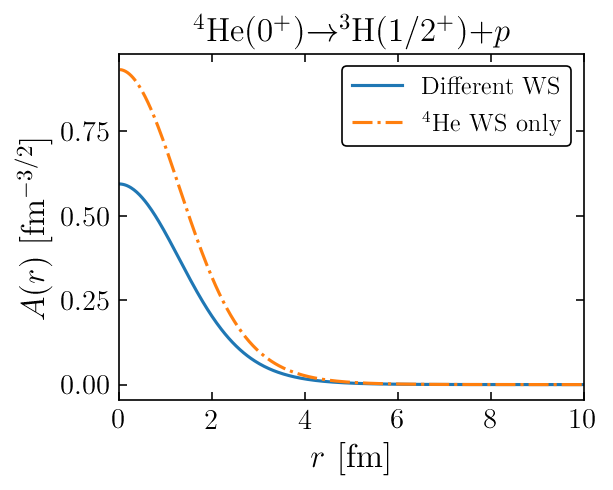

In [16]:
# Plot comparing to s.p. radial wave function
x_limits = (0, 10)
y_limits = None
plt.close('all')
f, ax = plt.subplots(figsize=(4, 3))
ax.plot(r_array, overlap_array, label='Different WS')
ax.plot(r_array, overlap_4He_array, label=r'$^4$He WS only', ls='dashdot')
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.legend(fontsize=12)
ax.set_xlabel(r"$r$ [fm]", fontsize=16)
ax.set_ylabel(r"$A(r)$ [fm$^{-3/2}$]", fontsize=16)
ax.set_title(r"$^{4}$He($0^+$)" + r"$\rightarrow$" + r"$^3$H($1/2^+$)"
             + r"$+p$", fontsize=16)
plt.show();

## Test Seminole parametrization

In [17]:
# Different WS on each side
ws_psi = IsospinAntisymmetric('H3', 2, 2, 'seminole')
# ws_psi = IsospinAntisymmetric('He4', 2, 2, 'seminole')  # Sanity check
ws_phi = IsospinAntisymmetric('He4', 2, 2, 'seminole')
so = OverlapIsospinAntisymmetric(ws_psi, ws_phi)
n_alpha, l_alpha, j_alpha, m_t_alpha = 1, 0, 1/2, 1/2  # Proton 1s_{1/2}
r_array, overlap_array = so.compute_overlap(n_alpha, l_alpha, j_alpha,
                                            m_t_alpha)
check_normalization(r_array, overlap_array)

Normalization = 0.85349


In [18]:
# Same WS on both sides gives A_\alpha(r) = u_\alpha(r) / r
nucleus_name, Z, N = 'He4', 2, 2
n, l, j, m_t = 1, 0, 1/2, 1/2  # 1s_{1/2}
filename = f"p.n{n-1}.l{l}.j{int(2*j)}.orb"
directory = f'../data/woods_saxon/seminole/{nucleus_name}/'
data = np.loadtxt(directory + filename)
r_array = data[:, 0]
u_array = data[:, 1]
overlap_4He_array = u_array / r_array
check_normalization(r_array, overlap_4He_array)

Normalization = 1.00000


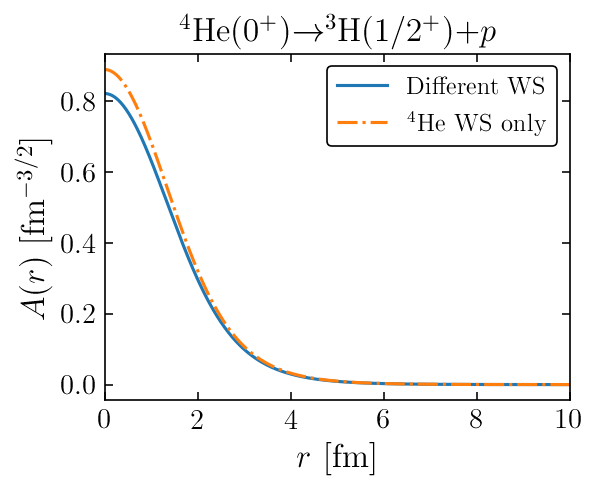

In [19]:
# Plot comparing to s.p. radial wave function
x_limits = (0, 10)
y_limits = None
plt.close('all')
f, ax = plt.subplots(figsize=(4, 3))
ax.plot(r_array, overlap_array, label='Different WS')
ax.plot(r_array, overlap_4He_array, label=r'$^4$He WS only', ls='dashdot')
ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.legend(fontsize=12)
ax.set_xlabel(r"$r$ [fm]", fontsize=16)
ax.set_ylabel(r"$A(r)$ [fm$^{-3/2}$]", fontsize=16)
ax.set_title(r"$^{4}$He($0^+$)" + r"$\rightarrow$" + r"$^3$H($1/2^+$)"
             + r"$+p$", fontsize=16)
plt.show();

In [20]:
# Save in .dat form
data_both = np.vstack((r_array, overlap_array)).T
np.savetxt('overlap_two_ws.dat', data_both)
data_4He = np.vstack((r_array, overlap_4He_array)).T
np.savetxt('overlap_only_4He_ws.dat', data_4He)